# Deterministic Neural Network

We fit a deterministic neural network that maps two inputs, x1 and x2, to output y

The surrogate is a width-32 `tanh` network with two layers

$$ \hat{\mathbf{y}}(x) = W_3 tanh(W_2 tanh(W_1 x + b_1) + b_2) + b_3 $$

In [19]:
# Import statements
import matplotlib.pyplot as plt
import os
import torch
import numpy as np
import pickle  # for data I/O
from sklearn.preprocessing import FunctionTransformer

from pypolymix.parameter_groups import DeterministicGroup
from pypolymix.surrogate_models import NeuralNetwork
from pypolymix import StochasticModel

In [20]:
# Set random seed
_ = torch.manual_seed(2048)

In [ ]:
# False: most recent model is loaded from disk instead of doing 5 minutes of training
TRAIN_MODEL = False

### Data Loading and Manipulation
The data is stored in a .pickle file in the current directory. After the pickle file is parsed into an object, the object has

- two inputs: obj['data']['x1'] and obj['data']['x2'], which are both Numpy Arrays
- one output: obj['data']['U']['u'], which is a Numpy Array

In [22]:
with open("Data_example_2D.pickle", "rb") as f:
    obj = pickle.load(f)

Data manipulation to get 2-D input and output tensors from the object.

In [23]:
def dict_to_tensors(obj):
    '''
    Input schema
    {
        'data': {
            'var1': np.array([values...]),  # Input variable 1
            'var2': np.array([values...]),  # Input variable 2
            ...
            'U': {
                'output1': np.array([values...]),  # Output variable 1
                'output2': np.array([values...]),  # Output variable 2
                ...
            }
        }
    }

    Note that all input and output keys map to numpy arrays of the same length
    
    Returns 2-D float tensor of input vars, 2-D float tensor of output vars
    '''
    output_dict = obj["data"]["U"]
    # k != x is a workaround
    # since Data_example_2D.pickle has 'x' already pre-built
    input_dict = {k: v for k, v in obj["data"].items() if k != "U" and k != 'x'}

    # conversion to numpy.ndarray done because of a warning that
    # creating a tensor from a list of numpy.ndarrays is extremely slow
    X_np = np.column_stack(list(input_dict.values())).astype(np.float32)
    Y_np = np.column_stack(list(output_dict.values())).astype(np.float32)
    return torch.from_numpy(X_np), torch.from_numpy(Y_np)

In [24]:
X, Y = dict_to_tensors(obj)
X

tensor([[-0.3398,  0.1949],
        [-0.0691, -0.1023],
        [-0.1798,  0.2994],
        ...,
        [35.0514, 49.5862],
        [34.6736, 49.7965],
        [35.0948, 49.7812]])

Here's a visualization of each individual input's relation to the output.

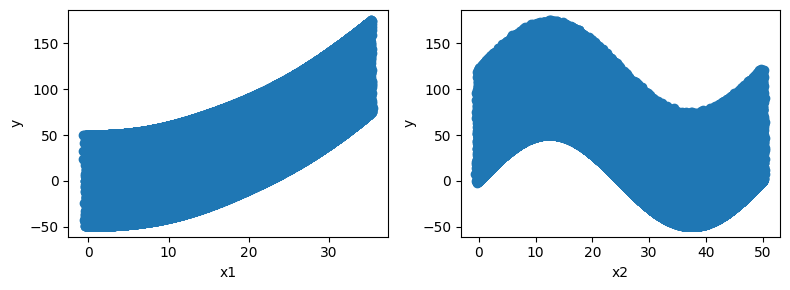

In [25]:
# Plot data
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (x, ax) in enumerate(zip(X.T, axes.flatten())):
    ax.scatter(x, Y)
    ax.set_xlabel(f"x{j + 1}")
    ax.set_ylabel(f"y")
plt.tight_layout()

A visualization of the relation of both inputs to the output.

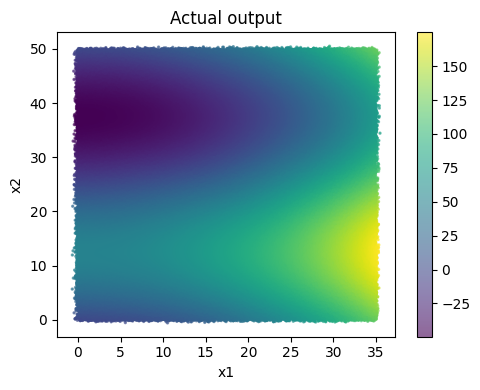

In [26]:
# Plot actual output over the 2-D input space
# X: shape [N, 2]
# Y: shape [N, 1]

# Convert to NumPy arrays for matplotlib
x1_np = X[:, 0].detach().cpu().numpy()
x2_np = X[:, 1].detach().cpu().numpy()
y_actual_np = Y[:, 0].detach().cpu().numpy()

# Plot actual output as color over x1-x2 space
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

c = ax.scatter(
    x1_np,
    x2_np,
    c=y_actual_np,
    s=2,
    alpha=0.6,
    cmap="viridis"
)

fig.colorbar(c, ax=ax)

ax.set_title("Actual output")
ax.set_xlabel("x1")
ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

### Model Configuration
We configure a width-32, depth-2 tanh network and print how many trainable parameters it contains so we have a sense of model capacity.

In [27]:
# Create a surrogate model
width = 32
depth = 2
# find num_inputs and num_outputs from the given data
num_inputs = X.shape[1]
num_outputs = Y.shape[1]
surrogate_model = NeuralNetwork(
    num_inputs=num_inputs, num_outputs=num_outputs,
    width=width, depth=depth, activation=torch.nn.functional.tanh
)
print(f"This model has {surrogate_model.num_params()} parameters")

This model has 1185 parameters


The parameters used are deterministic

In [28]:
# Create parameter groups
parameter_groups = DeterministicGroup("parameters", surrogate_model.num_params())

The `StochasticModel` is used as the Pypolymix model

In [29]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 1185 parameters


### Model Training

We pick learning-rate and weight-decay values, set a small `weight_factor` for the distribution loss, and build the AdamW optimizer plus `OneCycleLR` scheduler.

In [30]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
num_epochs = 10000    # Number of epochs

# Optimizer: AdamW
optimizer = torch.optim.AdamW(
    model.parameters(), lr=lr, weight_decay=weight_decay
)

# Loss
loss_fn = torch.nn.MSELoss(reduction="mean")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

If the TRAIN_MODEL flag is False, a previously trained model is loaded from ./my_training_results/pypolymix_nn_checkpoint.pt. 

Otherwise, the model is trained for many epochs. Each epoch samples the model parameters, evaluates the network, computes the mean squared error, and performs backpropagation. Then it updates the optimizer and the scheduler.

In [31]:
checkpoint_dir = "my_training_results"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "pypolymix_nn_checkpoint.pt")

if TRAIN_MODEL:
    # Train the stochastic model
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        # Evaluate parameters and model
        params = model.sample_parameters()
        Y_hat = surrogate_model(X, params)

        # Losses
        data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat))
        total_loss = data_loss

        # Backprop + step
        total_loss.backward()
        optimizer.step()
        scheduler.step()

        # Logging
        if (epoch + 1) % 100 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(
                f"Epoch {epoch + 1:5d} | "
                f"learning rate = {current_lr:.6f} | "
                f"data loss = {data_loss.item():.4f} | "
                f"total loss = {total_loss.item():.4f}"
            )

    # Save checkpoint after training finishes
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "width": width,
            "depth": depth,
            "num_inputs": num_inputs,
            "num_outputs": num_outputs,
            "lr": lr,
            "weight_decay": weight_decay,
            "num_epochs": num_epochs,
        },
        checkpoint_path,
    )

    print(f"Saved checkpoint to {checkpoint_path}")

else:
    # Load trained checkpoint and skip training
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    model.load_state_dict(ckpt["model_state_dict"])

    print(f"Loaded checkpoint from {checkpoint_path}")

Epoch   100 | learning rate = 0.000426 | data loss = 4227.2891 | total loss = 4227.2891
Epoch   200 | learning rate = 0.000505 | data loss = 3623.9780 | total loss = 3623.9780
Epoch   300 | learning rate = 0.000635 | data loss = 3237.1047 | total loss = 3237.1047
Epoch   400 | learning rate = 0.000815 | data loss = 2942.5486 | total loss = 2942.5486
Epoch   500 | learning rate = 0.001043 | data loss = 2596.2595 | total loss = 2596.2595
Epoch   600 | learning rate = 0.001317 | data loss = 2328.1904 | total loss = 2328.1904
Epoch   700 | learning rate = 0.001634 | data loss = 2051.9192 | total loss = 2051.9192
Epoch   800 | learning rate = 0.001989 | data loss = 1683.0507 | total loss = 1683.0507
Epoch   900 | learning rate = 0.002380 | data loss = 1453.0132 | total loss = 1453.0132
Epoch  1000 | learning rate = 0.002801 | data loss = 1268.5712 | total loss = 1268.5712
Epoch  1100 | learning rate = 0.003249 | data loss = 1102.1547 | total loss = 1102.1547
Epoch  1200 | learning rate = 0.

### Model Evaluation
TODO

In [32]:
GRID_SIZE = 200
x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()

x1_test = torch.linspace(x1_min, x1_max, GRID_SIZE)
x2_test = torch.linspace(x2_min, x2_max, GRID_SIZE)

X1_grid, X2_grid = torch.meshgrid(x1_test, x2_test, indexing="ij")
X_test = torch.stack([X1_grid.reshape(-1), X2_grid.reshape(-1)], dim=1)

model.eval()
# no gradient because this is prediction and not training
with torch.no_grad():
    Y_test = model(X_test, num_samples=1)
Y_test.shape

torch.Size([1, 40000, 1])

### Plotting Results
Here is a graph of the model's predicted values for evenly-spaced points.

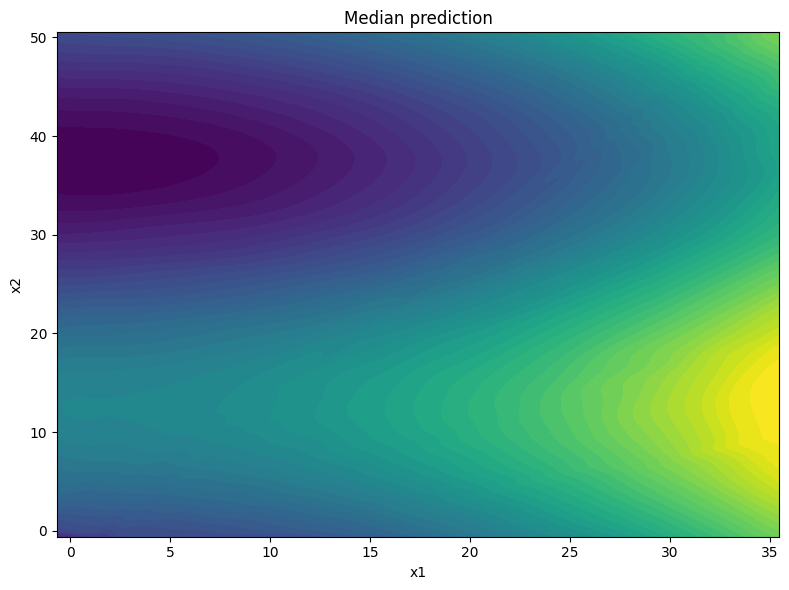

In [33]:
# Y_test: shape [1, 40000, 1]
y_samples = Y_test.squeeze(-1)  # [1, 40000]
y_prediction = y_samples.reshape(GRID_SIZE, GRID_SIZE)

# Reshape X_test back into 2-D grids
X1_grid = X_test[:, 0].reshape(GRID_SIZE, GRID_SIZE)
X2_grid = X_test[:, 1].reshape(GRID_SIZE, GRID_SIZE)

# Convert to NumPy arrays for matplotlib
X1_grid_np = X1_grid.detach().numpy()
X2_grid_np = X2_grid.detach().numpy()
y_prediction_np = y_prediction.detach().numpy()

# Plot prediction
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

c0 = ax.contourf(
    X1_grid_np,
    X2_grid_np,
    y_prediction_np,
    levels=50,
    cmap="viridis"
)
fig.colorbar(c0, ax=axes[0])
ax.set_title("Median prediction")
ax.set_xlabel("x1")
ax.set_ylabel("x2")


plt.tight_layout()
plt.show()

## Model Output

For visualizing training results, the GUI requires two files: `train_output.pickle` and `SM.pickle`

#### train_output.pickle

Contains the predictions and the actual values.

Stored as a dictionary with the following keys
- "U" -> a dictionary (str -> np.array) of the actual output values
- "Usm" -> a dictionary (str -> np.array) of the **s**urrogate **m**odel's predicted output values
- "unmapped" -> a dictionary (str -> np.array) of the input values

Note that the GUI assumes U and Usm are in a scaled output space. Our data has them in physical output space. To work around this, we use the physical values and provide an identity transform in SM["output_maps"]

In [34]:
def to_numpy_1d(x):
    """
    Convert torch tensor or array-like to flat NumPy array.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x).reshape(-1)


def predict_median_in_batches(model, X_tensor, num_samples=200, batch_size=20000):
    """
    Evaluate the stochastic model in batches and return the median prediction.

    Returns
    -------
    y_pred : np.ndarray, shape (N,)
    """
    model.eval()
    preds = []

    with torch.no_grad():
        for start in range(0, X_tensor.shape[0], batch_size):
            stop = start + batch_size
            X_batch = X_tensor[start:stop]

            # Shape: [num_samples, batch_size, num_outputs]
            Y_batch_samples = model(X_batch, num_samples=num_samples)

            # For one output, squeeze to [num_samples, batch_size]
            Y_batch_samples = Y_batch_samples.squeeze(-1)

            # Median over stochastic samples
            Y_batch_median = torch.quantile(Y_batch_samples, 0.5, dim=0)

            preds.append(Y_batch_median.detach().cpu())

    return torch.cat(preds, dim=0).numpy()


def make_triangular_grid_connectivity(grid_size):
    """
    Build triangular connectivity for a structured GRID_SIZE x GRID_SIZE grid.

    Assumes node ordering matches:
        node_id = i * GRID_SIZE + j

    Returns
    -------
    conn : np.ndarray, shape (2 * (grid_size - 1)^2, 3)
    """
    conn = []

    for i in range(grid_size - 1):
        for j in range(grid_size - 1):
            n00 = i * grid_size + j
            n01 = i * grid_size + (j + 1)
            n10 = (i + 1) * grid_size + j
            n11 = (i + 1) * grid_size + (j + 1)

            # Split each rectangular cell into two triangles
            conn.append([n00, n10, n11])
            conn.append([n00, n11, n01])

    return np.asarray(conn, dtype=np.int64)

In [35]:
output_dir = "my_training_results"
os.makedirs(output_dir, exist_ok=True)

input_names = ["x1", "x2"]
output_name = "u"

# -----------------------------
# Training/evaluation arrays
# -----------------------------

# Physical input arrays from training data
x1_physical = to_numpy_1d(X[:, 0])
x2_physical = to_numpy_1d(X[:, 1])

# Physical reference output from training data
u_reference_physical = to_numpy_1d(Y[:, 0])

# Surrogate prediction at the original training points
u_surrogate_physical = predict_median_in_batches(
    model,
    X,
    num_samples=200,
    batch_size=20000
)

training_result = {
    "U": {
        output_name: u_reference_physical,
    },
    "Usm": {
        output_name: u_surrogate_physical,
    },
    "unmapped": {
        "x1": x1_physical,
        "x2": x2_physical,
    }
}

# -----------------------------
# Mesh/nodal values for SM.pickle
# -----------------------------

# Use your existing prediction grid as the GUI mesh.
# X_test has shape [GRID_SIZE * GRID_SIZE, 2]
mesh_nodes = X_test.detach().cpu().numpy()

# Triangular connectivity for the structured grid
mesh_conn = make_triangular_grid_connectivity(GRID_SIZE)

# Use your median grid prediction as nodal values.
# If y_prediction already exists from your plotting cell:
u_nodal_physical = y_prediction.reshape(-1).detach().cpu().numpy()

# -----------------------------
# Identity maps
# -----------------------------
# Since we are saving physical values directly, inverse_transform should do nothing.
identity_map = FunctionTransformer(
    func=None,
    inverse_func=None,
    validate=False
)

SM = {
    "mesh": {
        "nodes": mesh_nodes,
        "conn": mesh_conn,
        # Do not include "M" unless you really have a meaningful n_nodes x n_nodes matrix.
    },
    "input_maps": {
        "x1": identity_map,
        "x2": identity_map,
    },
    "output_maps": {
        output_name: identity_map,
    },
    "nodal_values": {
        output_name: u_nodal_physical,
    },

    # Extra fields that may be useful to the GUI or future debugging
    "nodes_mapped": False,
    "constrained": False,
    "data_file": "Data_example_2D.pickle",
    "roi": {
        "x1": [float(np.min(x1_physical)), float(np.max(x1_physical))],
        "x2": [float(np.min(x2_physical)), float(np.max(x2_physical))],
        output_name: [
            float(np.min(u_reference_physical)),
            float(np.max(u_reference_physical))
        ],
    },
    "mesh_specs": {
        "element_numbers": {
            "x1": GRID_SIZE - 1,
            "x2": GRID_SIZE - 1,
        }
    },
}

# -----------------------------
# Save pickle files
# -----------------------------

training_result_path = os.path.join(output_dir, "training_result.pickle")
sm_path = os.path.join(output_dir, "SM.pickle")

with open(training_result_path, "wb") as f:
    pickle.dump(training_result, f)

with open(sm_path, "wb") as f:
    pickle.dump(SM, f)

print(f"Saved: {training_result_path}")
print(f"Saved: {sm_path}")

Saved: my_training_results/training_result.pickle
Saved: my_training_results/SM.pickle


# Absolute Error
Here we find how accurate the model is on an absolute scale. For relative error visualization, load train_output.pickle into the GUI at training result -> load training.

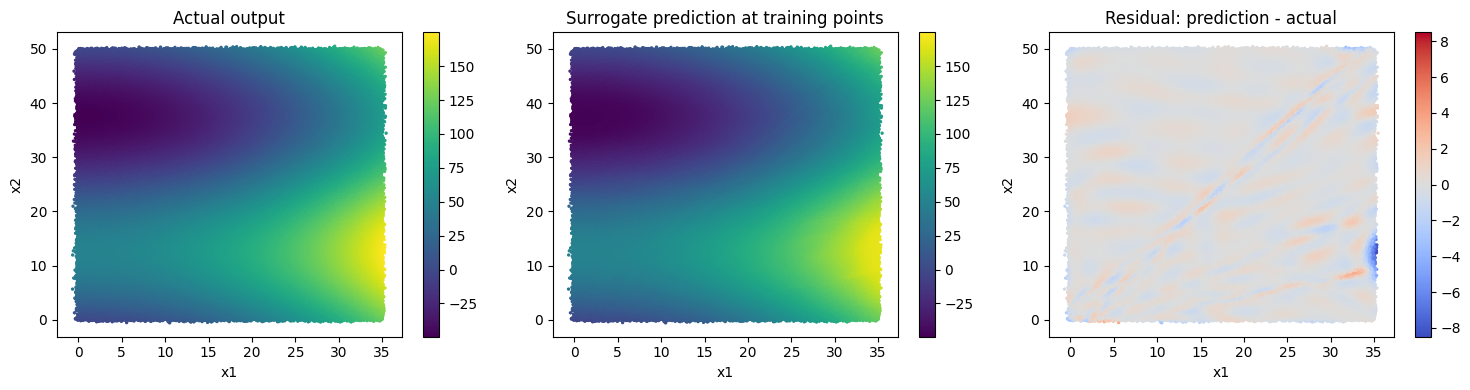

In [36]:
# Compare actual output and surrogate prediction at the original training points
# X: shape [N, 2]
# Y: shape [N, 1]

# Predict at original training points
u_surrogate_physical = predict_median_in_batches(
    model,
    X,
    num_samples=200,
    batch_size=20000
)

# Convert to NumPy arrays
x1_np = X[:, 0].detach().cpu().numpy()
x2_np = X[:, 1].detach().cpu().numpy()
u_actual_np = Y[:, 0].detach().cpu().numpy()
u_pred_np = u_surrogate_physical

# Residual
u_residual_np = u_pred_np - u_actual_np

# Use the same color scale for actual and predicted
vmin = min(u_actual_np.min(), u_pred_np.min())
vmax = max(u_actual_np.max(), u_pred_np.max())

# Symmetric color scale for residual
res_abs_max = np.max(np.abs(u_residual_np))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual output
c0 = axes[0].scatter(
    x1_np,
    x2_np,
    c=u_actual_np,
    s=2,
    alpha=1,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("Actual output")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# Surrogate prediction at training points
c1 = axes[1].scatter(
    x1_np,
    x2_np,
    c=u_pred_np,
    s=2,
    alpha=1,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("Surrogate prediction at training points")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

# Residual
c2 = axes[2].scatter(
    x1_np,
    x2_np,
    c=u_residual_np,
    s=2,
    alpha=1,
    cmap="coolwarm",
    vmin=-res_abs_max,
    vmax=res_abs_max
)
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("Residual: prediction - actual")
axes[2].set_xlabel("x1")
axes[2].set_ylabel("x2")

plt.tight_layout()
plt.show()